In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# CARGA DE DATASET Y EXPLORACION BASICA

In [14]:
df = pd.read_excel("Etapa 1 - Data ventas Mas Vision.xlsx", sheet_name="Hoja1")
df.rename(columns={'Cluster\n(Punto de venta)': 'Formato'}, inplace=True) # Renombramos para facilitar su manejo
print(" Primeros 5 registros del dataset (head) ")
display(df.head())

print("\n Información de tipos de datos y nulos (info) ")
print(df.info())

print("\n Estadísticas descriptivas de variables numéricas (describe) ")
display(df.describe())

 Primeros 5 registros del dataset (head) 


,id_suc,Formato,Año,Mes,Venta
0,1,E,2019,enero,20.026464
1,1,E,2019,febrero,20.021810
2,1,E,2019,marzo,20.250261
3,1,E,2019,abril,20.109109
4,1,E,2019,mayo,19.857730



 Información de tipos de datos y nulos (info) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26580 entries, 0 to 26579
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_suc   26580 non-null  int64  
 1   Formato  26580 non-null  object 
 2   Año      26580 non-null  int64  
 3   Mes      26580 non-null  object 
 4   Venta    26580 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 1.0+ MB
None

 Estadísticas descriptivas de variables numéricas (describe) 


,id_suc,Año,Venta
count,26580.000000,26580.000000,26580.000000
mean,222.000000,2021.800000,17.201131
std,127.885164,1.720497,5.580559
min,1.000000,2019.000000,0.000000
25%,111.000000,2021.000000,18.456741
50%,222.000000,2022.000000,18.895423
75%,333.000000,2023.000000,19.332233
max,443.000000,2024.000000,21.620904


In [8]:
# LIMPIEZA Y ESTANDARIZACIÓN

In [15]:
print(" Verificación de Valores Nulos ")
nulos = df.isnull().sum()
print("Total de valores nulos por columna:")
print(nulos)
print("-> Diagnóstico: La base de datos no contiene celdas vacías.")

print("\n Detección y Eliminación de Duplicados ")
duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("-> Acción: Registros duplicados eliminados exitosamente.")
else:
    print("-> Diagnóstico: No hay registros duplicados. La base es consistente.")

print("\n Estandarización de Texto y Tipos de Datos ")

df['Mes'] = df['Mes'].astype(str).str.lower().str.strip()
df['Formato'] = df['Formato'].astype(str).str.strip()

df['Venta'] = df['Venta'].astype(float)

print("Muestra de los datos estandarizados (Mes y Formato limpios):")
display(df[['Formato', 'Mes', 'Venta']].sample(5))

 Verificación de Valores Nulos 
Total de valores nulos por columna:
id_suc     0
Formato    0
Año        0
Mes        0
Venta      0
dtype: int64
-> Diagnóstico: La base de datos no contiene celdas vacías.

 Detección y Eliminación de Duplicados 
Registros duplicados encontrados: 0
-> Diagnóstico: No hay registros duplicados. La base es consistente.

 Estandarización de Texto y Tipos de Datos 
Muestra de los datos estandarizados (Mes y Formato limpios):


,Formato,Mes,Venta
17168,C,septiembre,0.000000
23460,A,enero,18.630658
26334,D,julio,18.791361
3021,E,octubre,19.652500
20685,F,octubre,19.290522


In [10]:
# CREANDO E INCORPORANDO TABLA DE DESCUENTOS

In [16]:
print(" Creación de la Tabla Paramétrica de Descuentos ")

# Definiendo los porcentajes de descuento promocionales por mes y tipo de producto
datos_descuentos = {
    'Mes': ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 
            'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'],
    'Descuento_Oftalmico': [0.10, 0.15, 0.10, 0.10, 0.20, 0.15, 0.10, 0.25, 0.15, 0.10, 0.30, 0.20],
    'Descuento_Solar':     [0.15, 0.20, 0.15, 0.20, 0.25, 0.25, 0.30, 0.20, 0.15, 0.15, 0.30, 0.25],
    'Descuento_Contacto':  [0.05, 0.10, 0.05, 0.05, 0.15, 0.10, 0.10, 0.15, 0.10, 0.05, 0.20, 0.15]
}

df_descuentos = pd.DataFrame(datos_descuentos)
display(df_descuentos)

print("\n Cruce (Merge) del Dataset Principal con Descuentos ")
# Unir la tabla de descuentos usando la columna 'Mes' como llave
df = pd.merge(df, df_descuentos, on='Mes', how='left')

print(f"Dimensiones del dataset enriquecido: {df.shape}")
print("\nMuestra de los datos con columnas de descuento incorporadas:")
display(df[['id_suc', 'Año', 'Mes', 'Venta', 'Descuento_Oftalmico', 'Descuento_Solar', 'Descuento_Contacto']].head(5))

 Creación de la Tabla Paramétrica de Descuentos 


,Mes,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto
0,enero,0.10,0.15,0.05
1,febrero,0.15,0.20,0.10
2,marzo,0.10,0.15,0.05
3,abril,0.10,0.20,0.05
4,mayo,0.20,0.25,0.15
5,junio,0.15,0.25,0.10
6,julio,0.10,0.30,0.10
7,agosto,0.25,0.20,0.15
8,septiembre,0.15,0.15,0.10
9,octubre,0.10,0.15,0.05



 Cruce (Merge) del Dataset Principal con Descuentos 
Dimensiones del dataset enriquecido: (26580, 8)

Muestra de los datos con columnas de descuento incorporadas:


,id_suc,Año,Mes,Venta,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto
0,1,2019,enero,20.026464,0.10,0.15,0.05
1,1,2019,febrero,20.021810,0.15,0.20,0.10
2,1,2019,marzo,20.250261,0.10,0.15,0.05
3,1,2019,abril,20.109109,0.10,0.20,0.05
4,1,2019,mayo,19.857730,0.20,0.25,0.15


In [17]:
# MAPEO NUMERICO Y CREACION DE COLUMNA DE FECHA

In [18]:
print(" Mapeo de Mes de Texto a Número ")

# Mapeo de diccionario para los 12 meses
mapa_meses = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4,
    'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8,
    'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

# Creando la columna Mes_Num
df['Mes_Num'] = df['Mes'].map(mapa_meses)

print("Mapeo completado exitosamente:")
display(df[['Mes', 'Mes_Num']].drop_duplicates().sort_values(by='Mes_Num'))

print("\n Creación de la Columna 'Fecha' (pd.to_datetime) ")

# Combinando Año y Mes_Num asignando el primer día de cada mes ('01')
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes_Num'].astype(str) + '-01')

print("Muestra de las nuevas columnas temporales:")
display(df[['id_suc', 'Año', 'Mes', 'Mes_Num', 'Fecha', 'Venta']].head(5))

print("\nInformación actualizada de tipos de datos:")
print(df[['Fecha', 'Mes_Num']].dtypes)

 Mapeo de Mes de Texto a Número 
Mapeo completado exitosamente:


,Mes,Mes_Num
0,enero,1
1,febrero,2
2,marzo,3
3,abril,4
4,mayo,5
5,junio,6
6,julio,7
7,agosto,8
8,septiembre,9
9,octubre,10



 Creación de la Columna 'Fecha' (pd.to_datetime) 
Muestra de las nuevas columnas temporales:


,id_suc,Año,Mes,Mes_Num,Fecha,Venta
0,1,2019,enero,1,2019-01-01,20.026464
1,1,2019,febrero,2,2019-02-01,20.021810
2,1,2019,marzo,3,2019-03-01,20.250261
3,1,2019,abril,4,2019-04-01,20.109109
4,1,2019,mayo,5,2019-05-01,19.857730



Información actualizada de tipos de datos:
Fecha      datetime64[ns]
Mes_Num             int64
dtype: object


In [19]:
# ANALISIS EXPLORATORIO (EDA)

 Estadísticas Descriptivas por Formato de Tienda 


,count,mean,std,min,25%,50%,75%,max
Formato,,,,,,,,
A,3000.0,17.45,4.30,0.0,18.16,18.44,18.73,19.94
B,120.0,14.61,8.32,0.0,14.48,18.64,20.76,21.62
C,4140.0,16.53,7.06,0.0,18.97,19.43,19.80,21.05
D,5220.0,18.68,2.07,0.0,18.58,18.88,19.19,20.62
E,7680.0,18.60,3.42,0.0,18.85,19.17,19.53,20.90
F,6360.0,14.69,7.66,0.0,17.91,18.55,18.88,20.23
G,60.0,15.51,6.68,0.0,16.26,18.29,19.04,20.39



 Análisis de Estacionalidad y Tendencia Temporal 


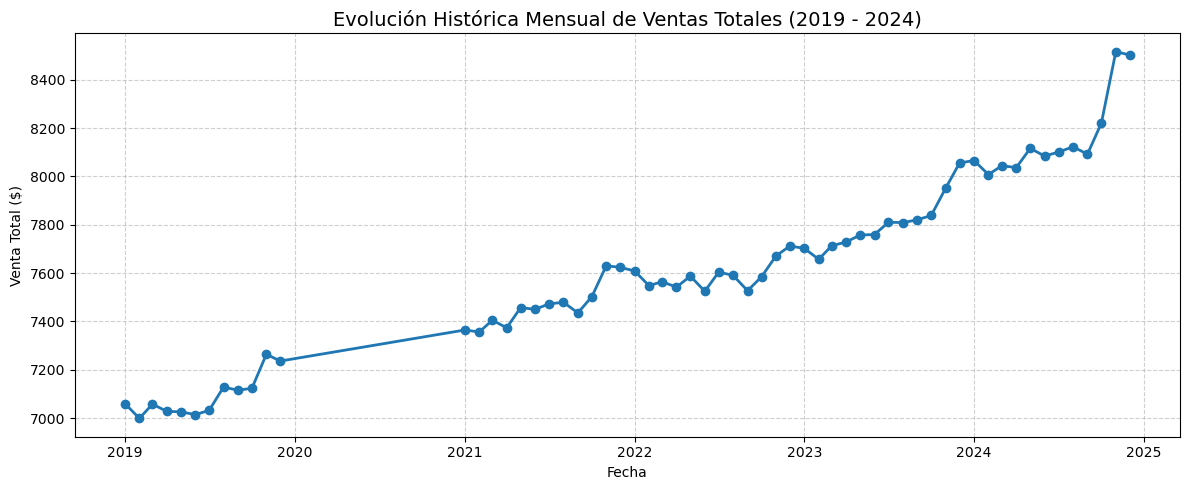


 Detección de Outliers (Método IQR y Diagrama de Caja) 
Límite Inferior: 17.14 | Límite Superior: 20.65
Total de registros atípicos (outliers): 2698 (10.15% del total)


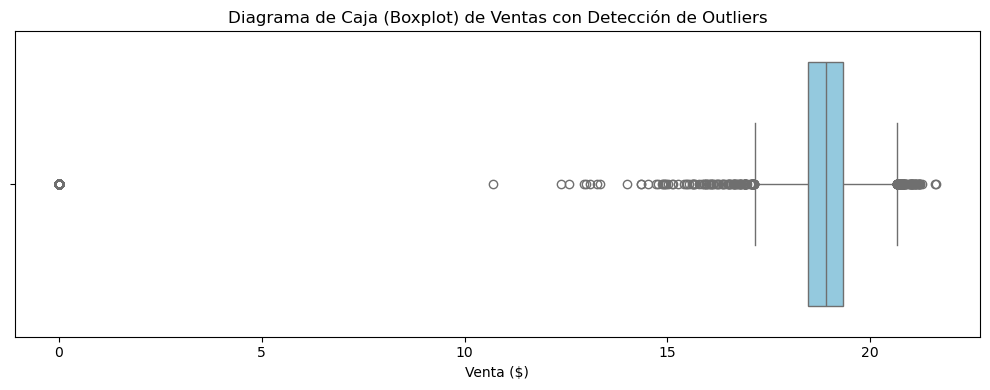


 Matriz de Correlación 


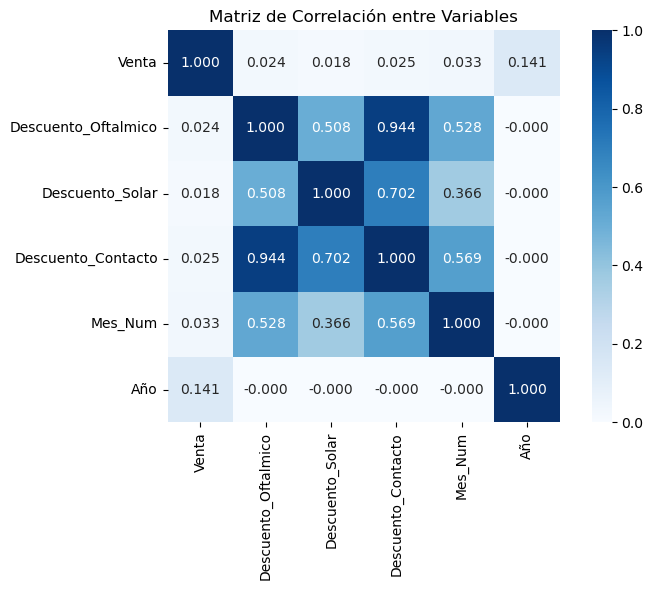

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print(" Estadísticas Descriptivas por Formato de Tienda ")
display(df.groupby('Formato')['Venta'].describe().round(2))

print("\n Análisis de Estacionalidad y Tendencia Temporal ")
# Agrupando por Fecha para ver la evolución continua
ventas_tiempo = df.groupby('Fecha')['Venta'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(ventas_tiempo['Fecha'], ventas_tiempo['Venta'], marker='o', color='#1f77b4', linewidth=2)
plt.title('Evolución Histórica Mensual de Ventas Totales (2019 - 2024)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Venta Total ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n Detección de Outliers (Método IQR y Diagrama de Caja) ")
Q1 = df['Venta'].quantile(0.25)
Q3 = df['Venta'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Venta'] < limite_inferior) | (df['Venta'] > limite_superior)]
print(f"Límite Inferior: {limite_inferior:.2f} | Límite Superior: {limite_superior:.2f}")
print(f"Total de registros atípicos (outliers): {len(outliers)} ({len(outliers)/len(df)*100:.2f}% del total)")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Venta'], color='skyblue')
plt.title('Diagrama de Caja (Boxplot) de Ventas con Detección de Outliers', fontsize=12)
plt.xlabel('Venta ($)')
plt.tight_layout()
plt.show()

print("\n Matriz de Correlación ")
columnas_interes = ['Venta', 'Descuento_Oftalmico', 'Descuento_Solar', 'Descuento_Contacto', 'Mes_Num', 'Año']
matriz_corr = df[columnas_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.3f', cmap='Blues', square=True)
plt.title('Matriz de Correlación entre Variables', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# GUARDAR DATASET ENRIQUECIDO

In [22]:
# Guardamos el DataFrame resultante en formato CSV con codificación UTF-8
nombre_archivo = "mas_vision_ventas_enriquecido.csv"
df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f"¡Dataset exportado exitosamente como '{nombre_archivo}'!")
print(f"Total de columnas guardadas: {df.shape[1]}")
print(f"Total de filas guardadas: {df.shape[0]}")

¡Dataset exportado exitosamente como 'mas_vision_ventas_enriquecido.csv'!
Total de columnas guardadas: 10
Total de filas guardadas: 26580
